# Практика 3

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
import tqdm.auto as tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torchsummary import summary

In [2]:
torch.manual_seed(42)
np.random.seed(42)

### Подготовка данных

В данной практике будем использовать Fashion MNIST. Набор картинок вещей. Для работы с датасетом загружаем его (скачиваем если его нет), настраиваем трансформации (базовые преобразования, которые должны быть применены ко всем объектам в датасете), например, конверсия в тензор или нормализация значений. Далее создаем подгрузчики данных и определяем классы (для интерпретации значений).

In [3]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
train_dataset = FashionMNIST('.', train=True, download=True, transform=mnist_transform)
test_dataset = FashionMNIST('.', train=False, transform=mnist_transform)

train_loader = DataLoader(list(train_dataset), batch_size=32, shuffle=True)
test_loader = DataLoader(list(test_dataset), batch_size=32, shuffle=False)

classes = ("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 187kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.7MB/s]


In [5]:
X, y = next(iter(train_loader))
X = X.numpy()
y = y.numpy()


print("Форма X:", X.shape)
print("Форма y:", y.shape)

print("\nПример y:")
print(y[:10])
print([classes[c] for c in y[:10]])

Форма X: (32, 1, 28, 28)
Форма y: (32,)

Пример y:
[5 7 4 7 3 8 9 5 3 1]
['Sandal', 'Sneaker', 'Coat', 'Sneaker', 'Dress', 'Bag', 'Ankle Boot', 'Sandal', 'Dress', 'Trouser']


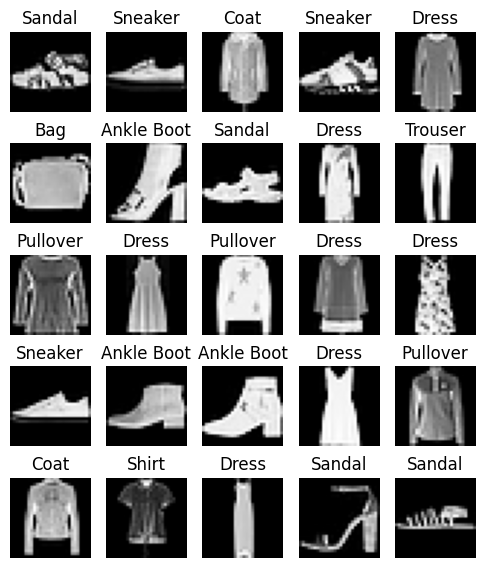

In [6]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(classes[y[i]])
    plt.axis('off')

In [7]:
print("Форма одной картинки:", X[0].shape)

Форма одной картинки: (1, 28, 28)


### Обучение

Попробуем обучать модель своими силами и силами библиотеки PyTorch.

В случае своих сил мы должны обновить параметры модели соответствуя градиентам на данном слое. Для этого на понадобится вычислить градиенты, пройтись по параметрам модели и применить градиенты.

```python
loss.backward()
with torch.no_grad():
    for param in model.parameters():
        if param.grad is not None:
            param.data -= learning_rate * param.grad.data
model.zero_grad()
```

P.S.

Контекстный менеджер `torch.no_grad` выключает вычисление градиентов, что позволяет использовать модель без влияния на обучения. Или же для изменения параметров модели.

In [8]:
def train_one_epoch(epoch, model, criterion, optimizer=None, scheduler=None, learning_rate=0.01):
    losses = []
    accuracies = []

    with tqdm.tqdm(train_loader) as pbar:
        for i, data in enumerate(pbar):
            x, y = data
            y_pred = model(x)
            loss = criterion(y_pred, y)

            if optimizer is None:
                loss.backward()
                with torch.no_grad():
                    for param in model.parameters():
                        if param.grad is not None:
                            param.data -= learning_rate * param.grad.data
                model.zero_grad()
            else:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())
            with torch.no_grad():
                accuracies.append((np.argmax(y_pred.numpy(), 1) == y).float().mean())

            pbar.set_description(f"Epoch {epoch}, loss: {np.mean(losses):.5f}")

    if scheduler is not None:
        scheduler.step()

    return losses, accuracies

In [9]:
def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    train_losses_flat = [loss for losses in train_losses for loss in losses]
    test_losses_flat = [loss for losses in test_losses for loss in losses]
    train_loss_avg = [np.mean(losses) for losses in train_losses]
    test_loss_avg = [np.mean(losses) for losses in test_losses]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)

    plt.plot(np.linspace(0, len(train_losses), len(train_losses_flat)), train_losses_flat, label="Train loss", color="#1974cf33")
    plt.plot(np.linspace(0, len(test_losses), len(test_losses_flat)), test_losses_flat, label="Test loss", color="#b2222233")

    plt.plot(np.linspace(0, len(train_losses), len(train_losses)), train_loss_avg, label=f"Train epoch loss (last={train_loss_avg[-1]:.2f})", color="#1974cf")
    plt.plot(np.linspace(0, len(test_losses), len(test_losses)), test_loss_avg, label=f"Test epoch loss (last={test_loss_avg[-1]:.2f})", color="#b22222")

    plt.xlabel("Epoches")
    plt.ylabel("Loss")
    plt.legend(loc=0)
    plt.grid("on")

    train_accuracies_flat = [acc for accs in train_accuracies for acc in accs]
    test_accuracies_flat = [acc for accs in test_accuracies for acc in accs]
    train_accuracy_avg = [np.mean(accs) for accs in train_accuracies]
    test_accuracy_avg = [np.mean(accs) for accs in test_accuracies]

    plt.subplot(1, 2, 2)

    plt.plot(np.linspace(0, len(train_accuracies), len(train_accuracies_flat)), train_accuracies_flat, label="Train accuracy", color="#1974cf33")
    plt.plot(np.linspace(0, len(test_accuracies), len(test_accuracies_flat)), test_accuracies_flat, label="Test accuracy", color="#b2222233")

    plt.plot(np.linspace(0, len(train_accuracies), len(train_accuracies)), train_accuracy_avg, label=f"Train epoch accuracy (last={train_accuracy_avg[-1]:.2f})", color="#1974cf")
    plt.plot(np.linspace(0, len(test_accuracies), len(test_accuracies)), test_accuracy_avg, label=f"Test epoch accuracy (last={test_accuracy_avg[-1]:.2f})", color="#b22222")

    plt.xlabel("Epoches")
    plt.ylabel("Accuracy")
    plt.legend(loc=0)
    plt.grid("on")
    plt.show()

In [10]:
def train(epochs, model, criterion, optimizer=None, scheduler=None, learning_rate=0.01):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        train_losses.append([])
        test_losses.append([])
        train_accuracies.append([])
        test_accuracies.append([])

        model.train(True)
        l, a = train_one_epoch(epoch, model, criterion, optimizer, scheduler, learning_rate)
        train_losses[-1] += l
        train_accuracies[-1] += a

        model.eval()
        with torch.no_grad():
            for i, vdata in enumerate(test_loader):
                x, y = vdata
                y_pred = model(x)
                test_losses[-1].append(criterion(y_pred, y))
                test_accuracies[-1].append((np.argmax(y_pred, 1) == y).float().mean())

    plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

#### Модель

Сделаем простейшую модель из полносвязных линейных слоев между которыми ReLU. Первый слой принимает 28\*28 (размер картинки) значений, но в виде линейного вектора, потому перед передачей в слой мы должны сделать данные плоскими `x.view(-1, 28 * 28)`.

В отличии от самописных сетей PyTorch автоматически считает градиенты, автоматически обрабатывает батчинг. От нас остается правильно скрепить данные кирпичики и не ошибится в размерностях входов и выходов.

In [11]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.l1 = nn.Linear(28 * 28, 100)
        self.l2 = nn.Linear(100, 100)
        self.l3 = nn.Linear(100, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = self.l3(x)
        return x

model = MyModel()
model

MyModel(
  (l1): Linear(in_features=784, out_features=100, bias=True)
  (l2): Linear(in_features=100, out_features=100, bias=True)
  (l3): Linear(in_features=100, out_features=10, bias=True)
)

In [12]:
summary(model, (1, 1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 100]          78,500
            Linear-2                  [-1, 100]          10,100
            Linear-3                   [-1, 10]           1,010
Total params: 89,610
Trainable params: 89,610
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.34
Estimated Total Size (MB): 0.35
----------------------------------------------------------------


### Обучение вручную

Обучая самостоятельно мы должны сами контролировать как мы вычитаем градиент, какая у нас скорость обучения. Слишком низкая скорость, ничему не научимся. Слишком большая - будет постоянно перелетать оптимальные значения весов. Неправильно вычтем градиенты - модель сломается.

  0%|          | 0/1875 [00:00<?, ?it/s]

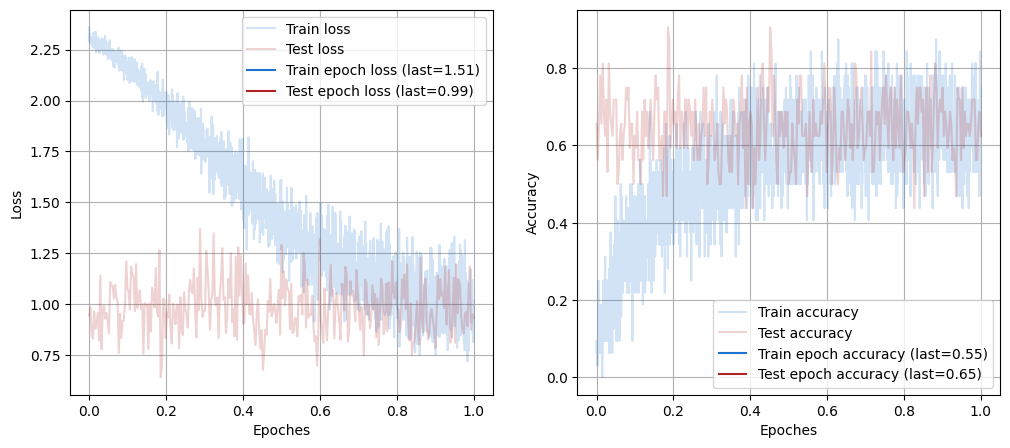

In [13]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
train(1, model, criterion, learning_rate=0.001)

  0%|          | 0/1875 [00:00<?, ?it/s]

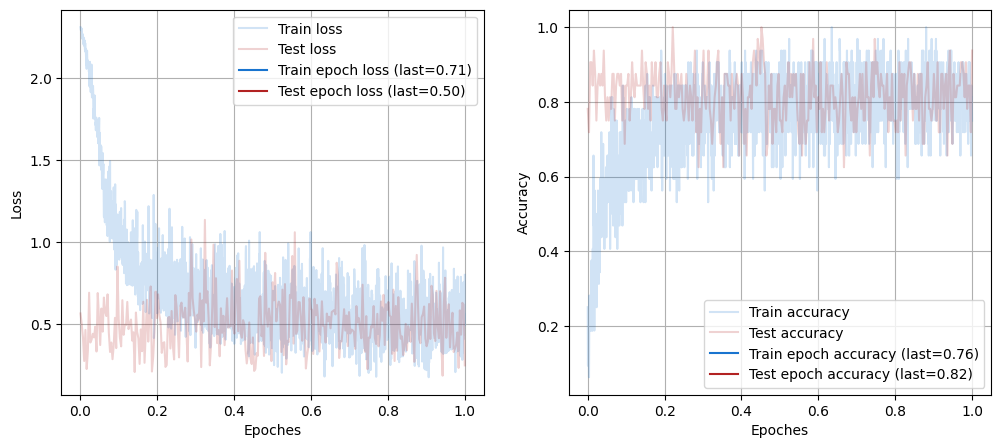

In [14]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
train(1, model, criterion, learning_rate=0.01)

  0%|          | 0/1875 [00:00<?, ?it/s]

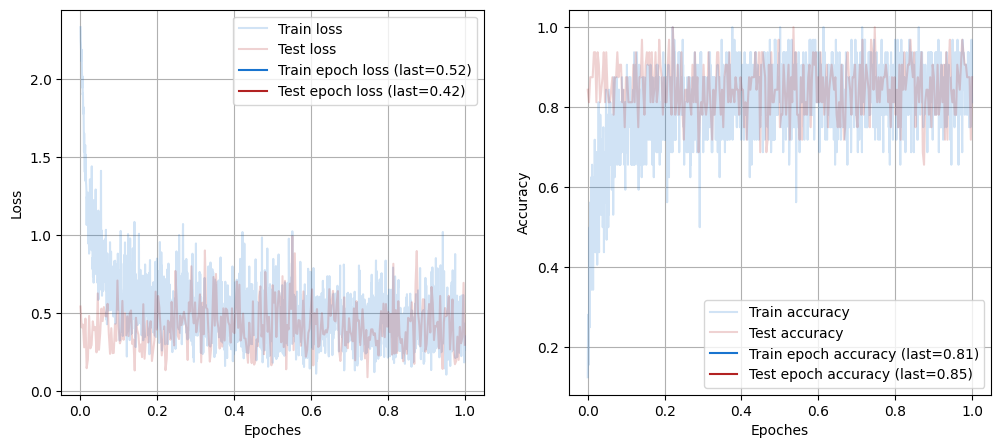

In [15]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
train(1, model, criterion, learning_rate=0.05)

  0%|          | 0/1875 [00:00<?, ?it/s]

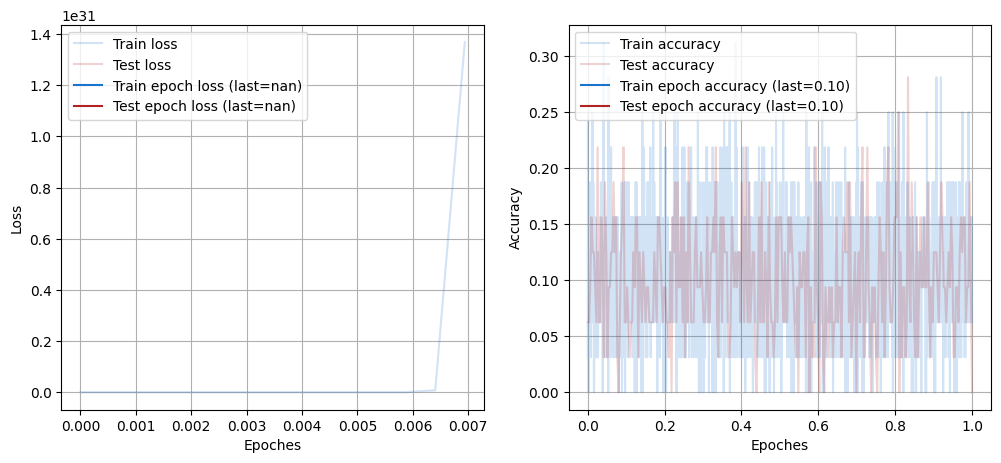

In [16]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
train(1, model, criterion, learning_rate=1)

### Оптимизаторы

Иногда трудно самостоятельно настраивать веса из-за сложности модели, сложности логики или просто не оптимально. На помощь приходят оптимизаторы, специально построенные классы, которые контролируют процесс изменения весов модели и даже учитывают направления изменения для оптимального сдвига весов. Например, если мы всегда изменяем вес в одну сторону, то возможно стоит ускорить этот процесс добавив механизм инерции.

Для достижения схожего с ручном процесса можно воспользоваться [SGD оптимизатором](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html) или же по другому стохастическим градиентным спуском (stochastic gradient descent). Градиентный спуск - изменение весов относительно всех доступных данных. SGD - итеративное изменение относительно для множества набора данных, что приводит к стохастическому процессу оптимизации градиентного спуска.

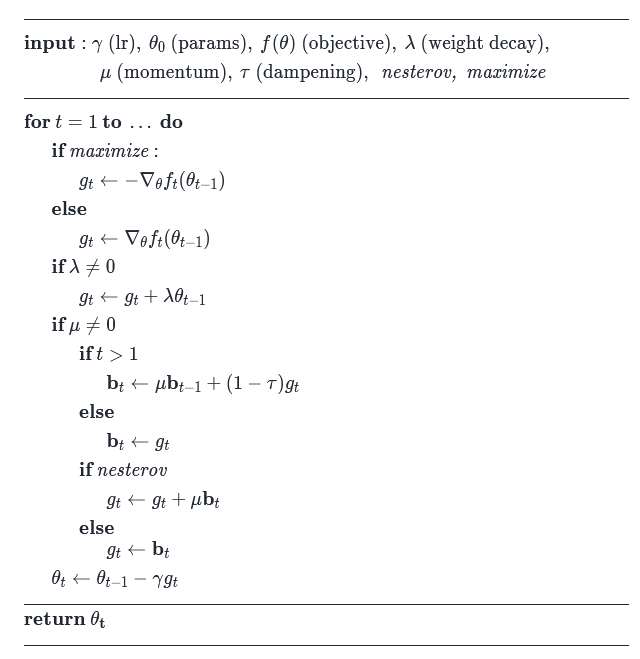

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

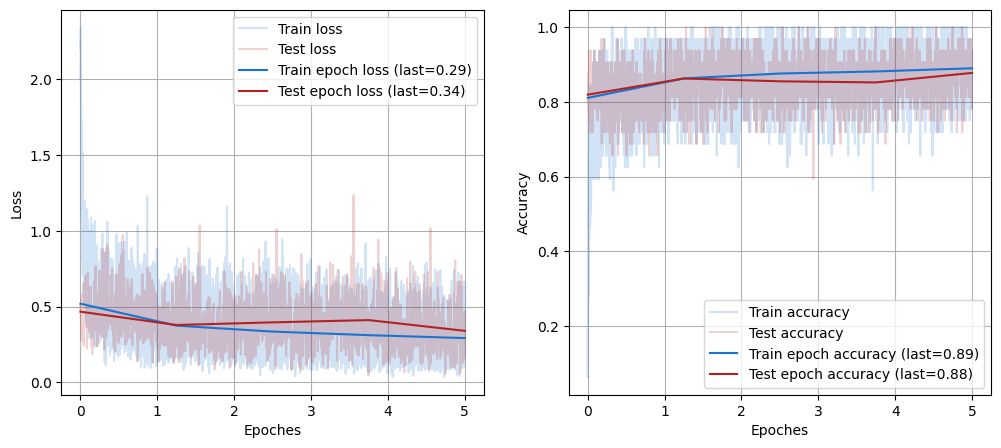

In [17]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
train(5, model, criterion, learning_rate=0.05)

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

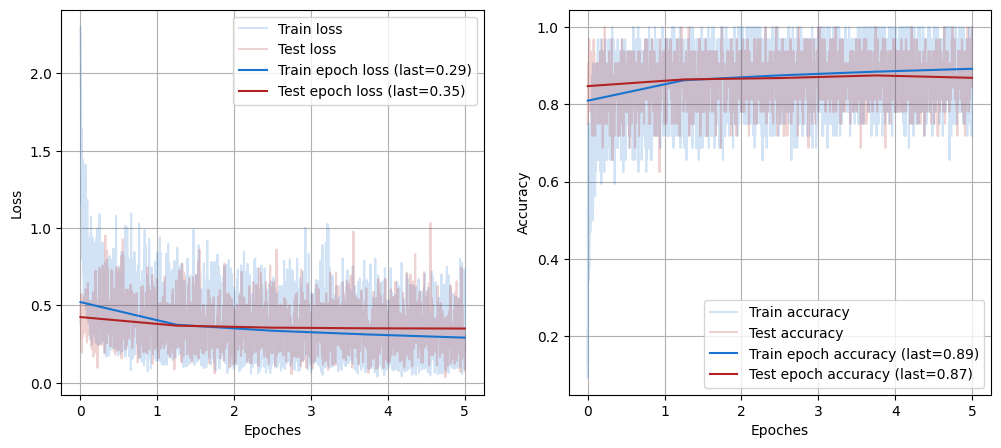

In [18]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
train(5, model, criterion, optimizer)

#### Другие оптимизаторы

Но не всегда стахастический градиентный спуск справляется с задачей. Конечно есть и его продвинута версия с инерцией и затуханием, но это лишь простой алгоритм. Для достижения более высоких результатов можно воспользоваться [ продвинутыми алгоритмами](https://docs.pytorch.org/docs/stable/optim.html#algorithms).

Главная идея оптмизаторов помимо SGD является скорость и в целом возможность достижения глобального минимума. Оптимизиаторы использя эвристики и другие эффекты (инерцию и т.п.) пытаются либо достичь минимума быстрее, либо найти альтернативные минимумы.

![](https://raw.githubusercontent.com/usr-ein/usr-ein/a068b84b31b42b18c59cf7ee5cd71a75e2a61eef/images/optimizers.gif)

Далее воспользуемся оптимизатором Adam.

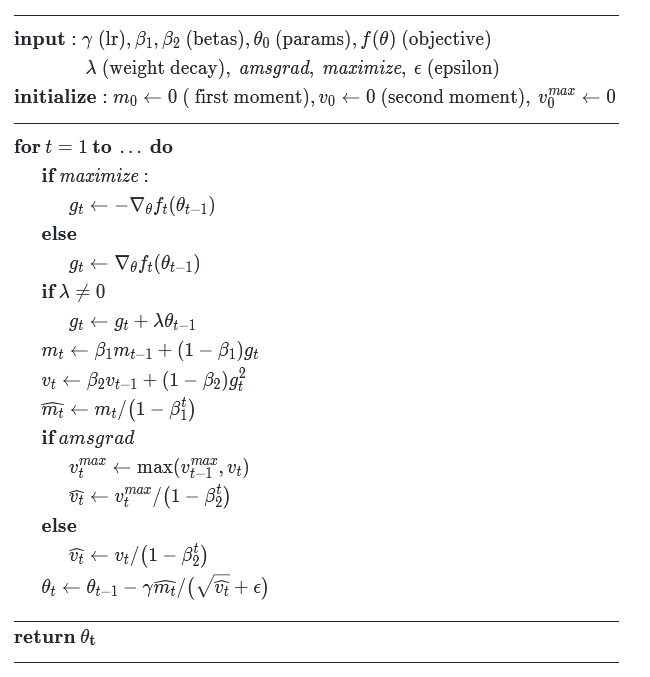

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

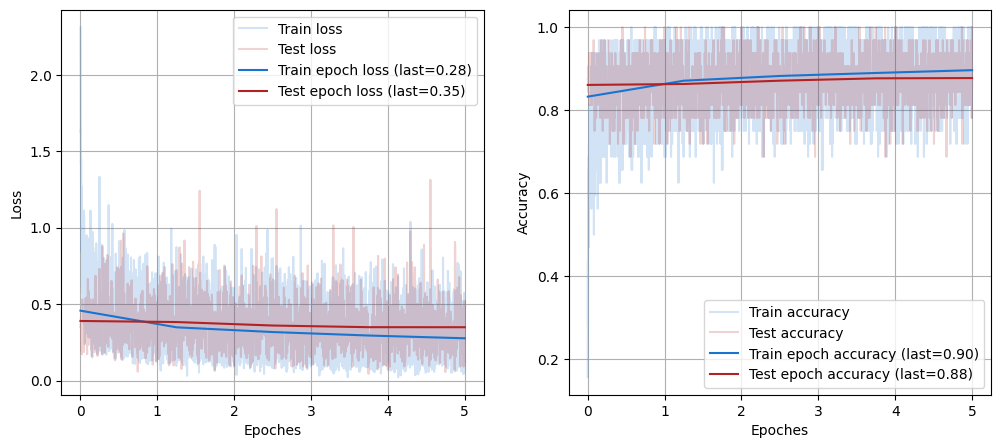

In [19]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
train(5, model, criterion, optimizer)

### Планировщики

Оптимизаторы обычно не котролируют скорость обучения, потому они также подвержены колебаниям при подходе к минимуму.

Можно изменять скорость обучения в ручную, уменьшая со временем (каждую эпоху) или по достижению определенной точности (по метрике).

Но можно воспользоваться планировщиками (schedulers), они в нужный момент сами настроют скорость обучения в зависимости от алгоритма.

Некоторые алгоритмы могут даже попытаться вывести обучение с мертвой точки резко увеличив скорость обучения.

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

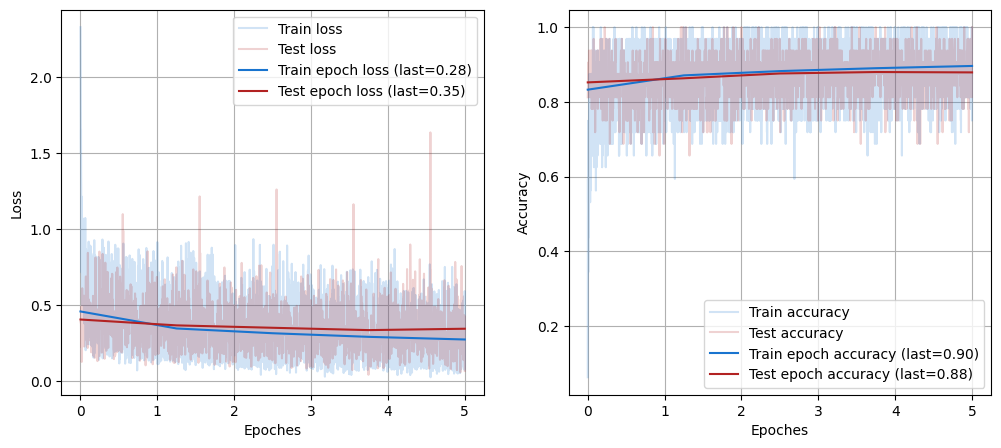

In [20]:
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
train(5, model, criterion, optimizer)

### CNN

Очевидно, что линейные слои не в полной мере могут обрабатывать пространственные данные.

Cверточные нейронные сети обрабатывают данные используя сверточные ядра. Иными словами нейросеть применяет специальные фильтры на участке входных данных.

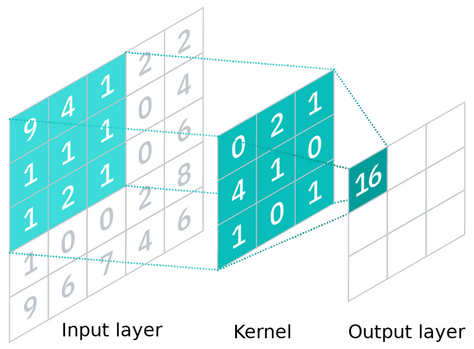

Разберем работу модели ниже:

In [21]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 9, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(9 * 14 * 14, 28)
        self.fc2 = nn.Linear(28, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 9 * 14 * 14)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNModel()
model

CNNModel(
  (conv1): Conv2d(1, 9, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1764, out_features=28, bias=True)
  (fc2): Linear(in_features=28, out_features=10, bias=True)
)

In [22]:
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 9, 28, 28]              90
         MaxPool2d-2            [-1, 9, 14, 14]               0
            Linear-3                   [-1, 28]          49,420
            Linear-4                   [-1, 10]             290
Total params: 49,800
Trainable params: 49,800
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.19
Estimated Total Size (MB): 0.26
----------------------------------------------------------------


Модель состоит из одного слоя свертки `self.conv1`, из пуллинга по максимуму `self.pool`, двух линеных слоев `self.fc*` и ReLU между сверткой и пуллингом и между линеными слоями.

#### Свертка

Свертка имеет размер ядра 3x3, значит ей требуется 9 весов на каждый канал входной канал (в нашем случае 1). Кроме того свертка имеет 9 выходных слоев, что значит мы должны создать 9 ядер и каждая из них имеет 9x1 весов.

Дополнительно свертка добавляет паддинг размером 1 из нулей вокруг картинки. Паддинг позволяет сохранить размер картинки. Ядро свертки имеет радиус 1, а значит захватывает лишнее значение по краям, без паддинга размер выходной картинки будет на 2 меньше.

В нашем случае входной размер 1x28x28 превращается в 9x28x28.  

Свертка PyTorch имеет возможность делать сдвиги, не-квадратные ядра, паддинги и т.д. Более подробно можно почитать [в документации](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html).


#### Пуллинг

Пуллинг имеет алгоритм проще, он имеет ядро 2x2 и проходит с шагом 2, а значит он уменьшает размер картинки из 28x28 в 14x14 без пересечения данных (за счет шага). При этом выбирается максимальное значение из ядра.

![](https://camo.githubusercontent.com/0e3f8d82e37ec229f780deb60667da4358d656b2099ed6ac0bfd6c5365f47bc1/68747470733a2f2f646576656c6f706572732e676f6f676c652e636f6d2f6d616368696e652d6c6561726e696e672f70726163746963612f696d6167652d636c617373696669636174696f6e2f696d616765732f6d6178706f6f6c5f616e696d6174696f6e2e676966)

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

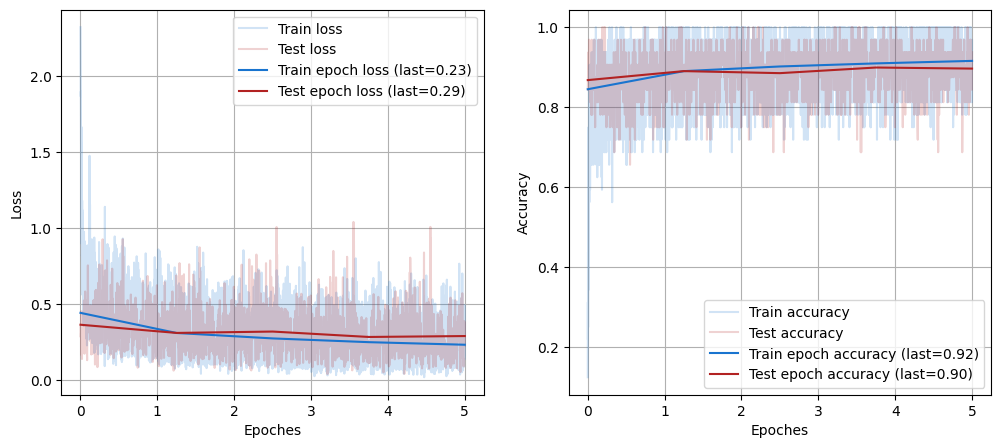

In [23]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
train(5, model, criterion, optimizer)

Результат очевиден. Даже простенький CNN позволяет обработать значительно лучше и это не предел.

Иногда свертки могут иметь больше слоев, весов и в целом долго работать с большими изображениями, но так как операции могут обрабатываються параллельно мы можем легко перевести все операции на видеокарту (которые легко обрабатывают параллельные вычисления).

In [24]:
print("Количество обучаемых весов в линейной модели:", sum([math.prod(param.shape) for param in MyModel().parameters() if param.requires_grad]))
print("Количество обучаемых весов в CNN:", sum([math.prod(param.shape) for param in CNNModel().parameters() if param.requires_grad]))

Количество обучаемых весов в линейной модели: 89610
Количество обучаемых весов в CNN: 49800


## Что дальше?

### Доработка модели

Тут все просто - меняйте блоки, добавляйте активационные функции, меняйте ошибку, метрики оценки. Пробуйте RNN, CNN, трансформеры. Полет фантазий.

### Подбор ошибок

Ошибка не всегда идеально передает сущность проблемы, потому требуется подбирать/создавать функции ошибки под каждую задачу.

Например:

MSE плохо справляется в ситуациях, когда в данных присутствуют сильные выбросы. Сильные ошибки, возникающие из-за этих выбросов, при возведении в квадрат становятся экстремально большими, искажая среднее значение ошибки. Модель, обученная с MSE, будет стремиться минимизировать эти гигантские ошибки, что может привести к тому, что она будет плохо предсказывать “нормальные” (невыбросовые) значения.

MAE, напротив. Поскольку ошибка берется по модулю, большие ошибки влияют на среднее значение пропорционально своей величине, а не квадратично. Это делает MAE более подходящей метрикой, когда данные содержат аномалии, и мы хотим, чтобы модель была более устойчивой к ним. Но это может понизить точность так как ошибки имеют схожий вес, однако иногда при обучении мы должны реагировать на большие ошибки сильнее (как в MSE).

### Подбор метрик

Ошибка это не метрика. Зачастую они используются как синонимы, однако они концептуально различаются.

Цель функции ошибки - контролировать процесс обучения. Она используется внутри алгоритма оптимизации и её градиент влияет на веса модели. Функция ошибки может быть не интерпретируемой, а значит её значения могут быть не связаны с качеством модели напрямую. Например, при значении MSE в 0.4 одна модель может иметь точность 0.9, а другая модель при значении 0.2 (что лучше) иметь точность 0.3 (что значительно хуже).

Метрика предназначена для оценки качества модели после того, как она была обучена. Она предоставляет человеку (или автоматической системе оценки) понятное и интерпретируемое представление о том, насколько хорошо модель работает.

Метрика может быть недифференцируема, а значит нельзя вычислить градиент и нельзя на основе неё обучить модель.

### Аугментация данных

Во время обучения можно увеличить обучающую выборку добавив в неё немного измененные оригинальные данные: немного повернув, сдвинув или добавив шума. Это позволяет подготовить модель к реальным данным, если аугментации соответствуют действительности. Например, звук записи не всегда идеален, потому и при обучении мы можем добавлять шум, ускорить или замедлить запись, все это может увеличить точность.

Но не стоит переусердствовать. Слишком сильно повернув картинку (например, цифру) или зашумив данные мы только запутаем модель.

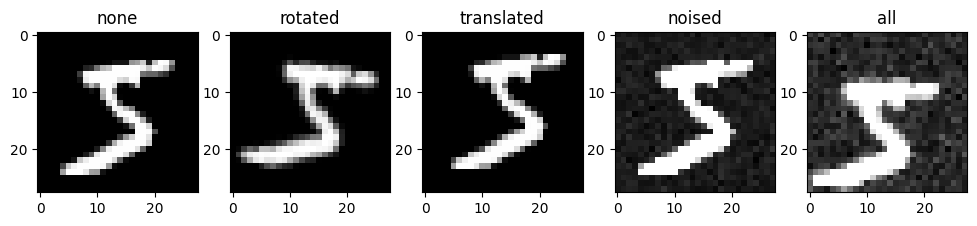

### Залезть внутрь модели

Интерпретация модели немаловажная часть исследования и разработки решений. Некоторые модели по типу однослойных линейных слоев интерпретировать не сложно - там каждый вес определяет насколько параметр коррелирует с выходом. В более сложных моделях надо уже делать срезы данных на слоях во время обучения или инференса (использования). Например, можно очень легко понять что выучивают ядра сверточной сети, если отрисовать то что они возвращают. Исходя из этого можно улучшать модель дальше - дорабатывая датасет, аугментируя данные, добавляя новые слои или активации.

![](https://user-images.githubusercontent.com/64969369/194777431-ab49d284-4508-4cb4-8824-8dc8f0d32f49.gif)